Here we will train and optimize Graph Neural Networks (GNN) on the PDBind dataset. We will use data where affinities are evaluated in Kd vallues for couples of molecules and proteins, specifically those of the bigger group of the data set that represent a thousand couples of molecules with hydrolases. In order to have a better distribution of the kd values, we convert them in nM and compute their logarithm value.  

In [5]:
import pandas as pd
from preprocessing import PDBpreprocessing

raw_data = pd.read_csv("LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

(19121, 2)


,smiles,target
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765


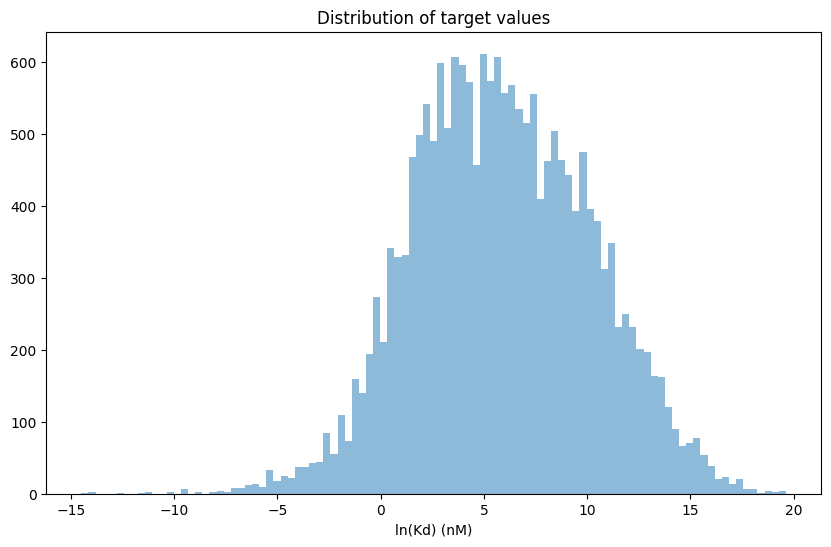

In [6]:
import numpy as np
X_plot = np.linspace(preprocessed_data['target'].min(), preprocessed_data['target'].max(), 100)
Y_plot = np.histogram(preprocessed_data['target'], bins=X_plot)[0]
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(X_plot[:-1], Y_plot, width=np.diff(X_plot), alpha=0.5)
plt.xlabel('ln(Kd) (nM)')
plt.title('Distribution of target values')
plt.show()

In [11]:
pip install 'numpy<2'

Note: you may need to restart the kernel to use updated packages.


Le fichier sp�cifi� est introuvable.


[17:04:54] Explicit valence for atom # 34 N, 4, is greater than permitted
[17:04:54] Unusual charge on atom 1 number of radical electrons set to zero
[17:04:54] Unusual charge on atom 2 number of radical electrons set to zero
[17:04:55] Unusual charge on atom 36 number of radical electrons set to zero
[17:04:55] Unusual charge on atom 12 number of radical electrons set to zero
[17:04:55] Unusual charge on atom 12 number of radical electrons set to zero
[17:04:55] Unusual charge on atom 16 number of radical electrons set to zero
[17:04:55] Explicit valence for atom # 3 N, 4, is greater than permitted
[17:04:55] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[17:04:55] Unusual charge on atom 16 number of radical electrons set to zero
[17:04:55] Explicit valence for atom # 3 N, 4, is greater than permitted
[17:04:55] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[17:04:55] Unusual charge on atom 17 number of radical electrons set to zero
[17:04:55] Unusual

✅ Dataset built: 19115 molecules
Node feature dim: 9


c:\Users\33695\Documents\GitHub\cheminfo_project\.venv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 001 | Train Loss: 20.9052 | Val Loss: 17.0679
Epoch 002 | Train Loss: 18.3668 | Val Loss: 16.8812
Epoch 002 | Train Loss: 18.3668 | Val Loss: 16.8812
Epoch 003 | Train Loss: 18.1185 | Val Loss: 16.7115
Epoch 003 | Train Loss: 18.1185 | Val Loss: 16.7115
Epoch 004 | Train Loss: 17.9904 | Val Loss: 16.6949
Epoch 004 | Train Loss: 17.9904 | Val Loss: 16.6949
Epoch 005 | Train Loss: 17.9017 | Val Loss: 16.5113
Epoch 005 | Train Loss: 17.9017 | Val Loss: 16.5113
Epoch 006 | Train Loss: 17.7562 | Val Loss: 16.4490
Epoch 006 | Train Loss: 17.7562 | Val Loss: 16.4490
Epoch 007 | Train Loss: 17.6664 | Val Loss: 16.3876
Epoch 007 | Train Loss: 17.6664 | Val Loss: 16.3876
Epoch 008 | Train Loss: 17.6082 | Val Loss: 16.3101
Epoch 008 | Train Loss: 17.6082 | Val Loss: 16.3101
Epoch 009 | Train Loss: 17.5878 | Val Loss: 16.4740
Epoch 009 | Train Loss: 17.5878 | Val Loss: 16.4740
Epoch 010 | Train Loss: 17.5060 | Val Loss: 16.2588
Epoch 010 | Train Loss: 17.5060 | Val Loss: 16.2588
Epoch 011 | 

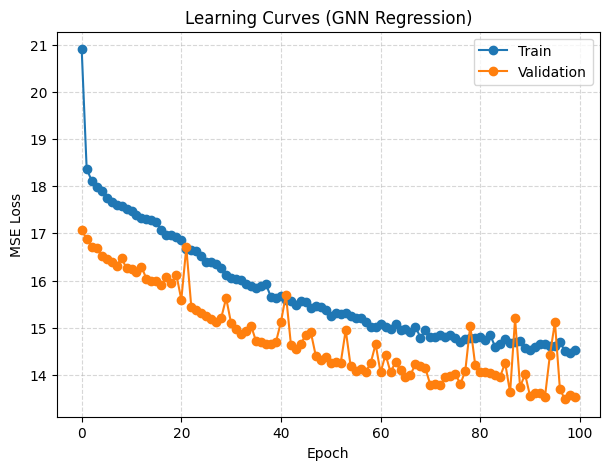

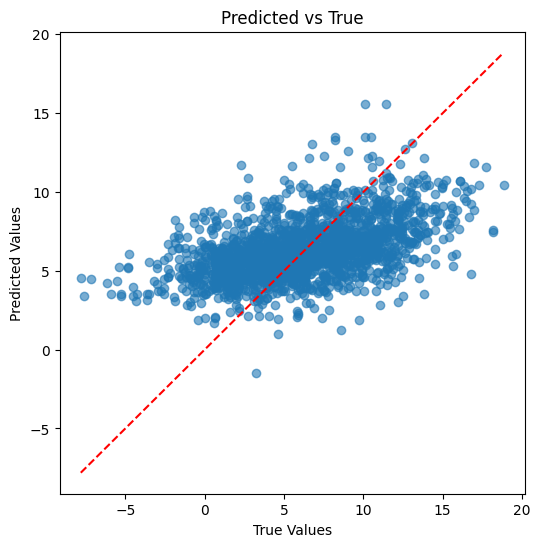

In [10]:
# ===============================================
# GNN Regression on preprocessed_data (SMILES + target)
# ===============================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, InMemoryDataset, DataLoader
from ogb.utils import smiles2graph
from rdkit import Chem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

# ------------------------------
# Config
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_dim = 64
batch_size = 64
epochs = 100
lr = 1e-3

# ===============================================
# Step 1 — Build dataset from preprocessed_data
# ===============================================

preprocessed_data = preprocessed_data[preprocessed_data['smiles'].apply(lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)].reset_index(drop=True)

class InMemorySMILESDataset(InMemoryDataset):
    def __init__(self, df, transform=None, pre_transform=None):
        self.df = df.reset_index(drop=True)
        super().__init__(None, transform, pre_transform)
        self.data, self.slices = self.process_df()

    def process_df(self):
        data_list = []
        for smiles, y in tqdm(zip(self.df["smiles"], self.df["target"]), total=len(self.df), desc="Converting SMILES"):
            graph = smiles2graph(smiles)
            x = torch.tensor(graph["node_feat"], dtype=torch.float)
            edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
            edge_attr = torch.tensor(graph["edge_feat"], dtype=torch.float)
            y = torch.tensor([y], dtype=torch.float)
            data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))
        return self.collate(data_list)

# Create dataset directly from your DataFrame
dataset = InMemorySMILESDataset(preprocessed_data)
print(f"✅ Dataset built: {len(dataset)} molecules")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

# ===============================================
# Step 2 — Train / Val / Test Split
# ===============================================
num_graphs = len(dataset)
train_len = int(0.8 * num_graphs)
val_len = int(0.1 * num_graphs)
test_len = num_graphs - train_len - val_len

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ===============================================
# Step 3 — Model Definition (OGB-style)
# ===============================================
class GCNRegression(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim=1):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)

# Initialize model
model = GCNRegression(dataset[0].x.shape[1], hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

# ===============================================
# Step 4 — Training Loop
# ===============================================
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss += loss_fn(out, batch.y.view(-1)).item() * batch.num_graphs
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ===============================================
# Step 5 — Evaluation on Test Set
# ===============================================
model.eval()
ys, preds = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        ys.append(batch.y.view(-1).cpu().numpy())
        preds.append(out.cpu().numpy())

ys = np.concatenate(ys)
preds = np.concatenate(preds)

mse = mean_squared_error(ys, preds)
r2 = r2_score(ys, preds)
print(f"\nTest MSE: {mse:.4f} | R²: {r2:.4f}")

# ===============================================
# Step 6 — Visualization
# ===============================================
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train", marker="o")
plt.plot(val_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curves (GNN Regression)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Scatter plot of predictions
plt.figure(figsize=(6, 6))
plt.scatter(ys, preds, alpha=0.6)
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()], "r--")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True")
plt.show()


+ Learning curve test/validation before optimization